I. Tạo nhãn cho các session

In [2]:
import pandas as pd

# Đọc các file
train_df = pd.read_csv("C:/Users/Acer/0. CAPSTONE/train_split_Depression_AVEC2017.csv")
dev_df = pd.read_csv("C:/Users/Acer/0. CAPSTONE/dev_split_Depression_AVEC2017.csv")
test_df = pd.read_csv("C:/Users/Acer/0. CAPSTONE/full_test_split.csv")

# Đổi tên cột trong test_df cho khớp định dạng
test_df = test_df.rename(columns={
    'PHQ_Score': 'PHQ8_Score',
    'PHQ_Binary': 'PHQ8_Binary'
})

# Gộp lại toàn bộ
all_labels_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

# Lọc các participant ID bạn cần
target_ids = [301, 302, 303, 304, 305, 306, 308, 309, 311, 319, 321]
filtered_df = all_labels_df[all_labels_df['Participant_ID'].isin(target_ids)]

# Tạo dict nhãn: {participant_id (string): score}
labels_dict = {
    str(row['Participant_ID']).strip().split('.')[0]: row['PHQ8_Score'] for _, row in filtered_df.iterrows()
}

print(" Đã tạo nhãn cho các session:")
for sid, score in labels_dict.items():
    print(f"  {sid}: PHQ-8 score = {score}")


 Đã tạo nhãn cho các session:
  303: PHQ-8 score = 0.0
  304: PHQ-8 score = 6.0
  305: PHQ-8 score = 7.0
  319: PHQ-8 score = 13.0
  321: PHQ-8 score = 20.0
  302: PHQ-8 score = 4.0
  301: PHQ-8 score = 3.0
  306: PHQ-8 score = 0.0
  308: PHQ-8 score = 22.0
  309: PHQ-8 score = 15.0
  311: PHQ-8 score = 21.0


In [19]:
import numpy as np

# Danh sách session theo đúng thứ tự embedding
session_ids = ['301', '302', '303', '304', '305', '306', '308', '309', '311', '319','321']

# Tạo vector nhãn y tương ứng
y = np.array([labels_dict[sid] for sid in session_ids], dtype=np.float32)

# Lưu lại thành file .npy
np.save("embeddings/phq8_scores.npy", y)

print(" Đã lưu labels tại: embeddings/phq8_scores.npy")


 Đã lưu labels tại: embeddings/phq8_scores.npy


II. Kiểm tra và xử lý các embeddings cho concatenate

In [20]:
# Hàm đọc embedding an toàn
def load_embedding(path):
    arr = np.load(path, allow_pickle=True)
    
    if arr.shape == ():  # object 0 chiều, ví dụ dict
        arr = arr.item()
        if isinstance(arr, dict):
            arr = list(arr.values())
    
    if isinstance(arr, list) or isinstance(arr, tuple):
        arr = np.stack(arr)
        
    return arr


# Đường dẫn tới embedding
text_path = "embeddings/text_embeddings/all_text_embeddings.npy"
audio_path = "embeddings/audio_embeddings/all_audio_embeddings.npy"
video_path = "embeddings/video_embeddings/video_embeddings.npy"
labels_path = "embeddings/phq8_scores.npy"

# Load embedding
text = load_embedding(text_path)
audio = load_embedding(audio_path)
video = load_embedding(video_path)
labels = np.load(labels_path)

# Kiểm tra shape
print(" Text shape:", text.shape)
print(" Audio shape:", audio.shape)
print(" Video shape:", video.shape)
print(" Labels shape:", labels.shape)

# Gộp các đặc trưng lại → EARLY FUSION
X = np.concatenate([text, audio, video], axis=1)
y = labels


 Text shape: (11, 768)
 Audio shape: (11, 312)
 Video shape: (11, 3212)
 Labels shape: (11,)


In [5]:
X = np.concatenate([text, audio, video], axis=1)
y = labels
print("Input shape:", X.shape)  # Expect: (6, 768 + 312 + 3212)

Input shape: (11, 4292)


Kiểm tra các embedding riêng lẻ

In [21]:
def inspect_embedding(path, name):
    try:
        data = np.load(path, allow_pickle=True)

        if isinstance(data, dict) or isinstance(data.item(), dict):
            data = data.item()  # chuyển từ 0D object array thành dict
            print(f" {name} loaded: type=dict, total sessions = {len(data)}")

            # Kiểm tra vector đầu tiên
            first_key = list(data.keys())[0]
            sample = data[first_key]
            print(f" Sample embedding shape = {sample.shape}, dtype = {sample.dtype}")

            # Gộp thành array để kiểm tra NaN và shape
            all_embeddings = np.stack(list(data.values()))
            print(f" Stacked shape: {all_embeddings.shape}")
            nan_count = np.isnan(all_embeddings).sum()
            if nan_count > 0:
                print(f"  {name} contains {nan_count} NaN values")
            else:
                print(f" {name} has no NaNs")

            return all_embeddings, list(data.keys())  # Trả về cả key để kiểm tra đồng bộ
        else:
            print(f" {name} is not a dict or unexpected structure")
            return None, None
    except Exception as e:
        print(f" Error loading {name}: {e}")
        return None, None


In [22]:
text_emb, text_keys = inspect_embedding(text_path, "Text")
audio_emb, audio_keys = inspect_embedding(audio_path, "Audio")
video_emb, video_keys = inspect_embedding(video_path, "Video")


 Text loaded: type=dict, total sessions = 11
 Sample embedding shape = (768,), dtype = float32
 Stacked shape: (11, 768)
 Text has no NaNs
 Audio loaded: type=dict, total sessions = 11
 Sample embedding shape = (312,), dtype = float32
 Stacked shape: (11, 312)
 Audio has no NaNs
 Video loaded: type=dict, total sessions = 11
 Sample embedding shape = (3212,), dtype = float64
 Stacked shape: (11, 3212)
  Video contains 17292 NaN values


Text và Audio không chứa NaNs, Video chứa NaNs nhiều

Gán giá trị 0 vào cá cột hoàn toàn NaN

In [8]:
import numpy as np

video_emb_clean = video_emb.copy()

# Tính trung bình theo cột, bỏ qua NaN
col_mean = np.nanmean(video_emb_clean, axis=0)

# Với các cột toàn NaN → col_mean sẽ là NaN, ta thay bằng 0
col_mean = np.where(np.isnan(col_mean), 0, col_mean)

# Tìm vị trí NaN
inds = np.where(np.isnan(video_emb_clean))

# Thay NaN bằng col_mean
video_emb_clean[inds] = np.take(col_mean, inds[1])

# Kiểm tra
print("Video embeddings sau khi xử lý NaN:", video_emb_clean.shape)
print("Tổng số NaN còn lại:", np.isnan(video_emb_clean).sum())


Video embeddings sau khi xử lý NaN: (11, 3212)
Tổng số NaN còn lại: 0


C:\Users\Acer\AppData\Local\Temp\ipykernel_21788\2151908378.py:6: RuntimeWarning: Mean of empty slice
  col_mean = np.nanmean(video_emb_clean, axis=0)


In [23]:
X = np.concatenate([text_emb, audio_emb, video_emb_clean], axis=1)
print(" Embedding tổng hợp shape:", X.shape)


 Embedding tổng hợp shape: (11, 4292)


Early fushion & Late fushion

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# X đã có sẵn: shape (11, 4292)
# y là array: shape (11,), binary labels

loo = LeaveOneOut()
y_true, y_pred = [], []

model = LogisticRegression(max_iter=1000)

for train_idx, test_idx in loo.split(X):
    model.fit(X[train_idx], y[train_idx])
    pred = model.predict(X[test_idx])
    
    y_true.append(y[test_idx][0])
    y_pred.append(pred[0])

# Đánh giá
print("EARLY FUSION")
print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))


EARLY FUSION
Accuracy: 0.0
              precision    recall  f1-score   support

         0.0     0.0000    0.0000    0.0000       2.0
         3.0     0.0000    0.0000    0.0000       1.0
         4.0     0.0000    0.0000    0.0000       1.0
         6.0     0.0000    0.0000    0.0000       1.0
         7.0     0.0000    0.0000    0.0000       1.0
        13.0     0.0000    0.0000    0.0000       1.0
        15.0     0.0000    0.0000    0.0000       1.0
        20.0     0.0000    0.0000    0.0000       1.0
        21.0     0.0000    0.0000    0.0000       1.0
        22.0     0.0000    0.0000    0.0000       1.0

    accuracy                         0.0000      11.0
   macro avg     0.0000    0.0000    0.0000      11.0
weighted avg     0.0000    0.0000    0.0000      11.0



C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
# Tách riêng
X_text = text_emb         # shape (11, 768)
X_audio = audio_emb       # shape (11, 312)
X_video = video_emb_clean # shape (11, 3212)

loo = LeaveOneOut()
y_true, y_pred = [], []

# 3 mô hình riêng biệt
clf_text = LogisticRegression(max_iter=1000)
clf_audio = LogisticRegression(max_iter=1000)
clf_video = LogisticRegression(max_iter=1000)

for train_idx, test_idx in loo.split(X_text):
    # Huấn luyện từng mô hình
    clf_text.fit(X_text[train_idx], y[train_idx])
    clf_audio.fit(X_audio[train_idx], y[train_idx])
    clf_video.fit(X_video[train_idx], y[train_idx])
    
    # Predict xác suất
    prob_text = clf_text.predict_proba(X_text[test_idx])[0][1]  # P(class=1)
    prob_audio = clf_audio.predict_proba(X_audio[test_idx])[0][1]
    prob_video = clf_video.predict_proba(X_video[test_idx])[0][1]
    
    # Late Fusion = Trung bình xác suất
    avg_prob = np.mean([prob_text, prob_audio, prob_video])
    final_pred = 1 if avg_prob >= 0.5 else 0
    
    y_true.append(y[test_idx][0])
    y_pred.append(final_pred)

# Đánh giá
print("LATE FUSION")
print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))


LATE FUSION
Accuracy: 0.18181818181818182
              precision    recall  f1-score   support

         0.0     0.1818    1.0000    0.3077         2
         3.0     0.0000    0.0000    0.0000         1
         4.0     0.0000    0.0000    0.0000         1
         6.0     0.0000    0.0000    0.0000         1
         7.0     0.0000    0.0000    0.0000         1
        13.0     0.0000    0.0000    0.0000         1
        15.0     0.0000    0.0000    0.0000         1
        20.0     0.0000    0.0000    0.0000         1
        21.0     0.0000    0.0000    0.0000         1
        22.0     0.0000    0.0000    0.0000         1

    accuracy                         0.1818        11
   macro avg     0.0182    0.1000    0.0308        11
weighted avg     0.0331    0.1818    0.0559        11



C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc điểm PHQ-8
phq_scores = np.load("C:/Users/Acer/0. CAPSTONE/embeddings/phq8_scores.npy")

# Tạo DataFrame
df_labels = pd.DataFrame({'phq_score': phq_scores})

# Thêm nhãn trầm cảm: 1 = Trầm cảm, 0 = Không trầm cảm
df_labels['label'] = df_labels['phq_score'].apply(lambda x: 1 if x >= 10 else 0)


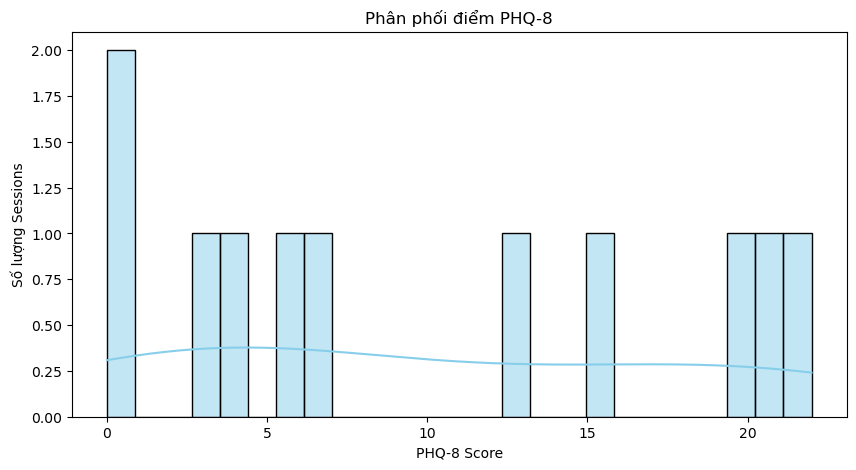

Tỉ lệ trầm cảm / không trầm cảm:
label
Không trầm cảm    0.545455
Trầm cảm          0.454545
Name: proportion, dtype: float64


In [27]:
# Vẽ histogram phân phối PHQ-8
plt.figure(figsize=(10, 5))
sns.histplot(df_labels['phq_score'], bins=25, kde=True, color='skyblue')
plt.title('Phân phối điểm PHQ-8')
plt.xlabel('PHQ-8 Score')
plt.ylabel('Số lượng Sessions')
plt.show()

# In tỉ lệ trầm cảm / không trầm cảm
label_counts = df_labels['label'].value_counts(normalize=True).rename({0: "Không trầm cảm", 1: "Trầm cảm"})
print("Tỉ lệ trầm cảm / không trầm cảm:")
print(label_counts)


In [28]:
from sklearn.metrics import mean_squared_error
import numpy as np

# MSE
mse = mean_squared_error(y_true, y_pred)

# RMSE
rmse = np.sqrt(mse)
print(f" EARLY FUSION - RMSE: {rmse:.9f}")

 EARLY FUSION - RMSE: 12.894678254


In [29]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Tính MSE, sau đó lấy căn để ra RMSE
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.4f}")


RMSE: 12.8947
